# TP2 : MCMC (Partie 2)

## G3 SDI - Estimation Avancée

Dans ce TP, on s'intéresse aux méthodes d'échantillonnage dites "MCMC" (Monte Carlo par Chaînes de Markov). Le premier exercice consiste à implémenter un Metropolis-Hastings et de regarder l'influence de quelques paramètres. Dans un deuxième exercice, on cherchera à implémenter un échantillonneur de Gibbs dans un modèle de régression linéaire bayésienne.

### Instructions

1. Renommez votre notebook sous la forme `tp2b_Nom1_Nom2.ipynb`. 

2. Votre code, ainsi que toute sortie du code, doivent être commentés !

3. Déposez votre notebook sur Moodle dans la section prévue à cet effet avant la date limite.

**Compte rendu — Ugo Roccamatisi.**


In [2]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as ss

### Exercice - Bayesian LASSO

Soit le modèle hiérarchique suivant, correspondant à un modèle de régression linéaire bayésienne :
\begin{align}
\sigma^2 & \sim \text{InverseGamma}(a_0, b_0) & \\
\tau_j & \sim \text{InverseGamma} \left(1, \frac{\lambda^2}{2} \right) \qquad & \forall~j \in {1, ..., p} \\
\beta_j | \tau_j, \sigma^2 & \sim \mathcal{N} \left( 0, \frac{\sigma^2}{\tau_j} \right) \qquad & \forall~j \in {1, ..., p} \\
y_i | \boldsymbol{x}_i, \boldsymbol{\beta}, \sigma^2 & \sim \mathcal{N}(\boldsymbol{\beta}^{\top} \mathbf{x}_i, \sigma^2) \qquad & \forall~i \in {1, ..., n} \\
\end{align}

On a :
* $y_i \in \mathbb{R}$ la variable que l'on cherche à prédire ;
* $\mathbf{x}_i \in \mathbb{R}^p$ les features ;
* $\boldsymbol{\beta} \in \mathbb{R}^p$ le vecteur de régression ;
* $\sigma^2$ la variance du bruit.
* $\boldsymbol{\tau} \in \mathbb{R}^p$ une variable latente du modèle.

$\lambda$, $a_0$, et $b_0$ sont quant à eux supposés connus et fixés.
  
Ce modèle s'appelle le *Bayesian LASSO* ([Park et al. (2008)](https://people.eecs.berkeley.edu/~jordan/courses/260-spring09/other-readings/park-casella.pdf)) (le .pdf de l'article est dans l'archive). Pour rappel, le LASSO correspond à la régression linéaire pénalisé en norme $\ell_1$.

À partir des données $\mathcal{D} = \{ (\mathbf{x}_1, y_1), ... (\mathbf{x}_n, y_n) \}$, l'objectif est de caractériser la loi a posteriori $p(\boldsymbol{\beta}, \boldsymbol{\tau}, \sigma^2 | \mathcal{D})$. Elle n'est pas tractable analytiquement. Nous allons donc échantillonner de cette loi a posteriori à l'aide d'un algorithme MCMC, plus précisémment, un [échantillonneur de Gibbs](https://fr.wikipedia.org/wiki/%C3%89chantillonnage_de_Gibbs).

On peut trouver les lois conditionnelles dans ce modèle :
\begin{align}
\boldsymbol{\beta} | \boldsymbol{\tau}, \sigma^2, \mathcal{D} \sim \mathcal{N}(\mathbf{A} \mathbf{X}^{\top} \mathbf{y}, \sigma^2 \mathbf{A}),
\end{align}
avec $\mathbf{A} = (\mathbf{X}^{\top} \mathbf{X} + \mathbf{D}_{\tau})^{-1}$, où $\mathbf{D}_{\tau} = \text{diag}(\tau_1, ..., \tau_p)$.
\begin{align}
\tau_j | \boldsymbol{\beta}, \sigma^2, \mathcal{D} \sim \text{InverseGaussian}\left( \frac{\lambda \sigma}{\beta_j}, \lambda^2 \right),
\end{align}
(Loi "Inverse-Gaussian" -> voir [ici](https://en.wikipedia.org/wiki/Inverse_Gaussian_distribution))
\begin{align}
\sigma^2 | \boldsymbol{\beta}, \boldsymbol{\tau}, \mathcal{D} \sim \text{InverseGamma}\left( a_0 + \frac{n+p}{2},~b_0 + \frac{1}{2} || \mathbf{y - X} \boldsymbol{\beta} ||^2_2 + \frac{1}{2} \boldsymbol{\beta}^{\top} \mathbf{D}_{\tau} \boldsymbol{\beta}  \right).
\end{align}

In [4]:
# Dataset

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X = X*np.sqrt(442) # Standardize, X is already centered
y = (y-np.mean(y))/np.std(y) # Zero-mean output, as no intercept in the model for simplicity

**Q1.** Écrire une fonction implémentant l'échantillonnage de Gibbs dans ce modèle, qui prend en arguments :
* Les données sous forme matricielle $\mathbf{X}$ et $\mathbf{y}$ ;
* Le nombre d'échantillons après burn-in $N_g$ ;
* La taille du *burn-in* $N_b$ ;
* Les hyperparamètres du modèle : $a_0,~b_0,~\lambda$.

Elle retourne $N_g$ échantillons du posterior $p(\boldsymbol{\beta}, \boldsymbol{\tau}, \sigma^2 | \mathcal{D})$. On pourra initialiser la chaîne en tirant de la loi a priori.

NB :
* Pour échantillonner d'une loi inverse gamma (a,b), on pourra utiliser `invgamma.rvs(a, loc=0, scale=b)`
* Pour échantillonner d'une loi inverse gaussian (m,l), on pourra utiliser `invgauss.rvs(m/l, loc=0, scale=l)`

In [6]:
def bayesian_lasso_gibbs(X,y,Ng,Nb,a0,b0,l,seed=42):
    """Gibbs sur (beta,tau,sigma²), avec tau = précision locale."""
    if min(Ng,Nb,a0,b0,l)<=0:raise ValueError('Arguments positifs requis')
    rng=np.random.default_rng(seed);n,p=X.shape
    beta=np.zeros(p);sigma2=ss.invgamma.rvs(a0,scale=b0,random_state=rng)
    tau=ss.invgamma.rvs(1,scale=l*l/2,size=p,random_state=rng)
    XtX=X.T@X;Xty=X.T@y
    betas=np.empty((Ng,p));taus=np.empty((Ng,p));variances=np.empty(Ng)
    for it in range(Nb+Ng):
        # beta | tau, sigma²,y : normale multivariée ; Cholesky pour stabilité.
        precision=XtX+np.diag(tau)
        chol=np.linalg.cholesky(precision)
        mean=np.linalg.solve(chol.T,np.linalg.solve(chol,Xty))
        beta=mean+np.sqrt(sigma2)*np.linalg.solve(chol.T,rng.normal(size=p))
        # tau_j | beta,sigma² : inverse-gaussienne, mu=lambda*sigma/|beta_j|.
        # La valeur beta_j=0 a probabilité nulle théoriquement ; clip protège le calcul.
        ig_mean=l*np.sqrt(sigma2)/np.maximum(np.abs(beta),1e-12)
        tau=ss.invgauss.rvs(mu=ig_mean/l**2,scale=l**2,random_state=rng)
        residual=y-X@beta
        shape=a0+(n+p)/2
        scale=b0+.5*(residual@residual+np.dot(tau,beta**2))
        sigma2=ss.invgamma.rvs(shape,scale=scale,random_state=rng)
        if it>=Nb:
            i=it-Nb;betas[i]=beta;taus[i]=tau;variances[i]=sigma2
    return betas,taus,variances

**Q2.** Faire tourner la chaîne MCMC avec les paramètres suivants : $N_g = 2000$, $N_b = 1000$, $a_0 = 1.5$, $b_0 = 1$, $\lambda = 10$.

* Afficher les *traceplots* pour $\sigma^2$ et quelques-uns des $\beta_p$. Commenter
* Pour tous les $\boldsymbol{\beta}$ et $\sigma^2$, afficher un histogramme ou un KDE des $N_g$ échantillons obtenus. Afficher sur le même plot la valeur de l'estimation MMSE. Enfin, donner l'intervalle de crédibilité à 95%.

MMSE β : [-0.    -0.117  0.323  0.181 -0.067 -0.024 -0.107  0.049  0.303  0.037]
ICr 95 % β (colonnes borne basse, haute) :
 [[-0.063  0.062]
 [-0.192 -0.04 ]
 [ 0.242  0.405]
 [ 0.104  0.263]
 [-0.232  0.054]
 [-0.147  0.099]
 [-0.226  0.008]
 [-0.057  0.191]
 [ 0.199  0.404]
 [-0.027  0.114]]
σ² moyen et ICr : 0.5087466239321572 [0.44748183 0.58094407]


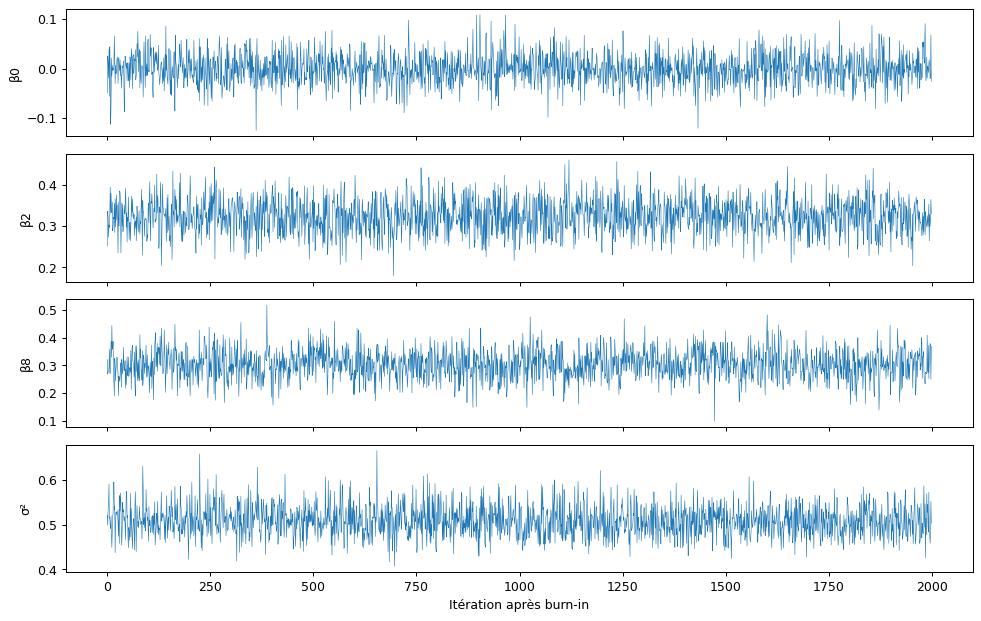

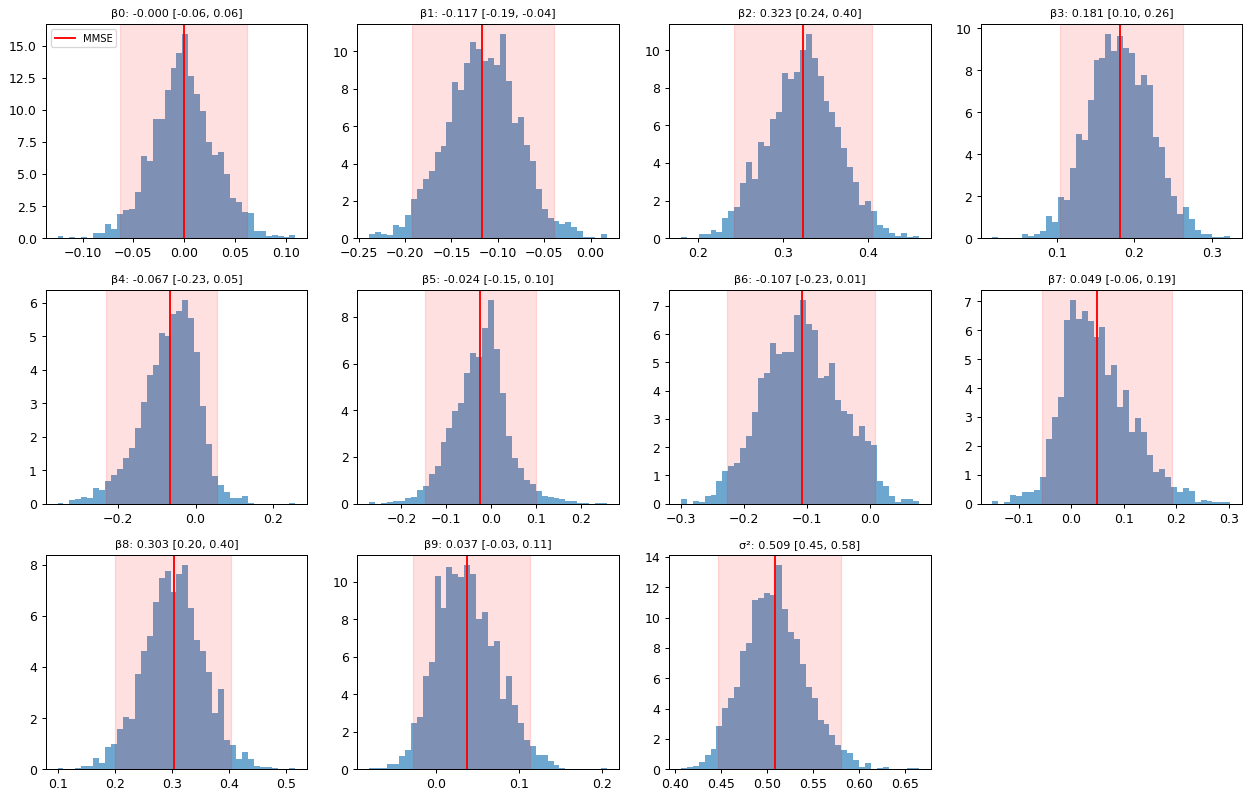

In [8]:
Ng=2000;Nb=1000;a0=1.5;b0=1;l=10
betas,taus,variances=bayesian_lasso_gibbs(X,y,Ng,Nb,a0,b0,l)
fig,axes=plt.subplots(4,1,figsize=(11,7),sharex=True)
for ax,j in zip(axes[:3],[0,2,8]):ax.plot(betas[:,j],lw=.45);ax.set(ylabel=f'β{j}')
axes[3].plot(variances,lw=.45);axes[3].set(xlabel='Itération après burn-in',ylabel='σ²');fig.tight_layout();plt.show()
fig,axes=plt.subplots(3,4,figsize=(14,9))
for j,ax in enumerate(axes.flat):
    if j>10:ax.axis('off');continue
    samples=betas[:,j] if j<10 else variances
    point=samples.mean();interval=np.quantile(samples,[.025,.975])
    ax.hist(samples,bins=40,density=True,alpha=.65)
    ax.axvline(point,c='red',label='MMSE');ax.axvspan(*interval,alpha=.12,color='red')
    ax.set_title(f'{"β"+str(j) if j<10 else "σ²"}: {point:.3f} [{interval[0]:.2f}, {interval[1]:.2f}]',fontsize=9)
axes.flat[0].legend(fontsize=8);fig.tight_layout();plt.show()
print('MMSE β :',np.round(betas.mean(axis=0),3))
print('ICr 95 % β (colonnes borne basse, haute) :\n',np.round(np.quantile(betas,[.025,.975],axis=0).T,3))
print('σ² moyen et ICr :',variances.mean(),np.quantile(variances,[.025,.975]))

**Réponse.** Les traceplots permettent de vérifier visuellement que la chaîne explore une région stable après burn-in ; ils ne prouvent pas à eux seuls la convergence. Les lignes rouges sont les moyennes a posteriori, et les intervalles colorés représentent les quantiles crédibles à 95 %. Des variables corrélées peuvent avoir des coefficients individuels incertains.

**Q3.** Générer 1000 échantillons de la loi prédictive a posteriori pour le nouveau point $x_{\text{new}}$ (défini dans le code) et tracer un histogramme ou un KDE. Commenter.

Moyenne prédictive et intervalle 95 % : -0.2554765717808786 [-1.74521752  1.26584627]


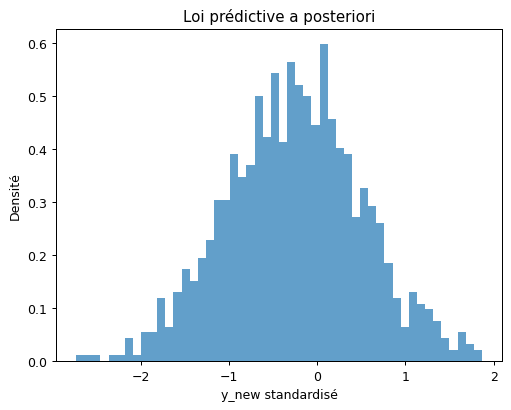

In [11]:
x_new=np.array([1.41145807,1.06548848,0.30006161,0.45984057,-0.52475728,-1.70643289,1.02259953,1.49710409,-1.25030999,0.84817082])
rng_pred=np.random.default_rng(123)
indices=rng_pred.choice(Ng,1000,replace=False)
# Chaque observation prédictive tire aussi un bruit neuf N(0,sigma²).
prediction=betas[indices]@x_new+rng_pred.normal(size=1000)*np.sqrt(variances[indices])
fig,ax=plt.subplots();ax.hist(prediction,bins=50,density=True,alpha=.7);ax.set(xlabel='y_new standardisé',ylabel='Densité',title='Loi prédictive a posteriori');plt.show()
print('Moyenne prédictive et intervalle 95 % :',prediction.mean(),np.quantile(prediction,[.025,.975]))

**Réponse.** La loi prédictive tient compte de l’incertitude sur β et σ² et ajoute le bruit d’une nouvelle observation. Elle est donc plus étalée que la simple distribution des valeurs x_newᵀβ.

**Résultat.** La moyenne prédictive en unités standardisées est **−0,255**, avec un intervalle prédictif empirique à 95 % **[−1,745 ; 1,266]**.


**Q4.** Étudier l'influence du paramètre $\lambda$ sur l'inférence des paramètres (prendre e.g. $\lambda = 1$ et $\lambda=100$). Commenter.

λ=10: ||E[β]||₁=1.209, moyenne σ²=0.509
λ=1: ||E[β]||₁=1.698, moyenne σ²=0.489
λ=100: ||E[β]||₁=0.601, moyenne σ²=0.681


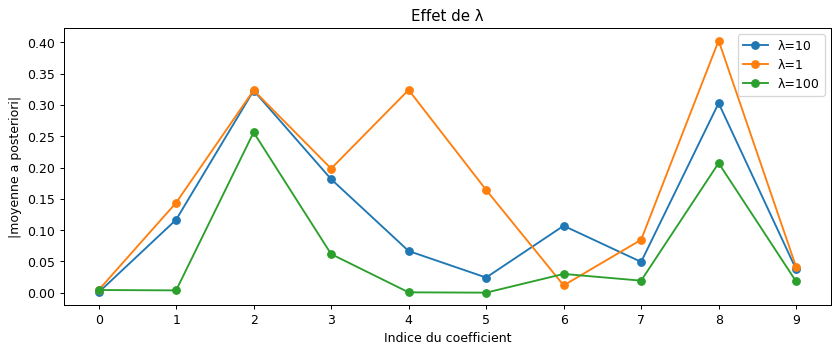

In [14]:
fits={10:(betas,variances)}
for strength in (1,100):
    bs,ts,vs=bayesian_lasso_gibbs(X,y,Ng=2000,Nb=1000,a0=a0,b0=b0,l=strength,seed=42)
    fits[strength]=(bs,vs)
fig,ax=plt.subplots(figsize=(11,4))
for strength,(bs,vs) in fits.items():ax.plot(np.arange(X.shape[1]),np.abs(bs.mean(axis=0)),'o-',label=f'λ={strength}')
ax.set(xticks=np.arange(X.shape[1]),xlabel='Indice du coefficient',ylabel='|moyenne a posteriori|',title='Effet de λ');ax.legend();plt.show()
for strength,(bs,vs) in fits.items():
    print(f'λ={strength}: ||E[β]||₁={np.abs(bs.mean(axis=0)).sum():.3f}, moyenne σ²={vs.mean():.3f}')

**Réponse.** Dans cette paramétrisation, augmenter λ concentre le prior marginal des β près de zéro et favorise une contraction plus forte. Les courbes de |E[β]| et les normes L1 affichées quantifient cet effet ; la corrélation des variables peut faire varier certains coefficients individuellement dans l’autre sens.

**Résultat.** La norme L1 de la moyenne des β passe de 1,698 (λ=1) à 1,209 (λ=10), puis à 0,601 (λ=100). Le shrinkage global augmente donc nettement.
